### Data Preprocessing

In [39]:
import pandas as pd
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 20)
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from scipy.stats import randint, uniform
import joblib
import csv
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import seaborn as sns

In [40]:
df = pd.read_csv("./datasets/new_raw.csv")
first = ["name", "nvar"]
df = df[first + [c for c in df.columns if c not in first]]
df["nvar"].value_counts
df = df.sort_values(["name", "nvar", "mem"]).reset_index()
df

,index,name,nvar,nvmops,objective,eval_duration_solver,extract_duration_solver,stats_elapsed_time,dual_feas,status,timed_bytes,timed_time,timed_gctime,nlp_warmup_time,mem,neval_grad,iter,source_solver,problem,neval_obj,timestamp_solver,error_solver,vector_type,extract_duration_problem,highest_degree (ExprTree),nln_nnzj,adbackend_hessian_backend_type,minimize,count_plus_minus,alloc_obj,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,tree_length,count_trigonometric_function,matrix_free,nlin,time_obj,tree_depth,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,count_exponential_function,islp,count_op_function,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,time_grad,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,eval_duration_problem,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,alloc_grad,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,total_alloc
0,15939,arglina,100,1.0,5.000000e+01,0.319062,0.011306,0.000135,7.841650e-15,first_order,18576.0,0.000164,0.000000,0.377710,1,4.0,1.0,OptimizationProb...,OptimizationProb...,4.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,7.712626e+07
1,15940,arglina,100,1.0,5.000000e+01,0.319062,0.011309,0.000151,7.841650e-15,first_order,22120.0,0.000199,0.000000,0.377710,2,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,7.712626e+07
2,15941,arglina,100,1.0,5.000000e+01,0.319062,0.011275,0.000140,7.841650e-15,first_order,25592.0,0.000182,0.000000,0.377710,3,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModel

In [41]:
feature_cols_reg = [
                    # Core Features
                    "nvar", 
                    "mem",
                    "tree_length", 
                    "tree_depth", 
                    "time_obj",  # initial eval
                    "time_grad",
                    "extract_duration_problem",
                    
                    # Expression Tree Features
                    "highest_degree (ExprTree)",
                    "count_plus_minus",
                    "count_trigonometric_function",
                    "count_exponential_function",
                    "count_op_function",

                    # allocation
                    "alloc_obj",
                    "alloc_grad",
                    "total_alloc",
                  ]

target_cols_reg = [ "neval_obj",
                    "neval_grad",
                    "timed_bytes"] #(neval_obj, neval_grad, timed_bytes)

target_col_model = ["stats_elapsed_time"]

group_key = ["name", "nvar"]                                                                                                                   # [...]     
all_cols = list(set(feature_cols_reg + target_cols_reg + target_col_model + group_key))
solver_metrics = ['neval_grad', 'neval_obj', 'timed_bytes']
df[solver_metrics] = df[solver_metrics].fillna(0)
df = df[all_cols]
df.isna().sum().sort_values(ascending=False)

tree_length                     0
tree_depth                      0
total_alloc                     0
neval_obj                       0
alloc_obj                       0
nvar                            0
timed_bytes                     0
mem                             0
stats_elapsed_time              0
time_obj                        0
count_op_function               0
alloc_grad                      0
count_trigonometric_function    0
count_exponential_function      0
neval_grad                      0
time_grad                       0
count_plus_minus                0
name                            0
extract_duration_problem        0
highest_degree (ExprTree)       0
dtype: int64

In [42]:
df = df.copy()
df["mem_count"] = df.groupby(["name", "nvar"]).transform('size')
df = df[df["mem_count"] == 100].copy().reset_index(drop=True)
df

,tree_length,tree_depth,extract_duration_problem,name,count_plus_minus,time_grad,neval_grad,count_exponential_function,count_trigonometric_function,alloc_grad,count_op_function,time_obj,stats_elapsed_time,mem,timed_bytes,nvar,alloc_obj,neval_obj,total_alloc,highest_degree (ExprTree),mem_count
0,10404.0,9.0,4.309682,arglina,305.0,0.464686,4.0,0.0,0.0,4.261110e+07,509.0,0.376715,0.000135,1,18576.0,100,34515160.0,4.0,7.712626e+07,2.0,100
1,10404.0,9.0,4.309682,arglina,305.0,0.464686,2.0,0.0,0.0,4.261110e+07,509.0,0.376715,0.000151,2,22120.0,100,34515160.0,2.0,7.712626e+07,2.0,100
2,10404.0,9.0,4.309682,arglina,305.0,0.464686,2.0,0.0,0.0,4.261110e+07,509.0,0.376715,0.000140,3,25592.0,100,34515160.0,2.0,7.712626e+07,2.0,100
3,10404.0,9.0,4.309682,arglina,305.0,0.464686,2.0,0.0,0.0,4.261110e+07,509.0,0.376715,0.000151,4,29128.0,100,34515160.0,2.0,7.712626e+07,2.0,100
4,10404.0,9.0,4.309682,arglina,305.0,0.464686,2.0,0.0,0.0,4.261110e+07,509.0,0.376715,0.000139,5,32600.0,100,34515160.0,2.0,7.712626e+07,2.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21495,425000.0,7.0,2813.283680,woods,275001.0,35.399378,59.0,0.0,0.0,2.573195e+10,575001.0,0.073713,1279.820757,96,314448744.0,100000,65309368.0,68.0,2.579726e+10,2.0,100
21496,425000.0,7.0,2813.283680,woods,275001.0,35.399378,59.0,0.0,0.0,2.573195e+10,575001.0,0.073713,1112.816634,97,317646328.0,100000,65309368.0,68.0,2.579726e+10,2.0,100
21497,425000.0,7.0,2813.283680,woods,275001.0,35.399378,59.0,0.0,0.0,2.573195e+10,575001.0,0.073713,1162.156092,98,320848008.0,100000,65309368.0,68.0,2.579726e+10,2.0,100
21498,425000.0,7.0,2813.283680,woods,275001.0,35.399378,59.0,0.0,0.0,2.573195e+10,575001.0,0.073713,1396.521273,99,324045592.0,100000,65309368.0,68.0,2.579726e+10,2.0,100


In [43]:
# unique instances: one row per (problem, nvar)
instances = df[group_key].drop_duplicates()

# shuffle instances
instances = instances.sample(frac=1, random_state=66).reset_index(drop=True)

n = len(instances)
n_train = int(0.8 * n)

train_inst = instances.iloc[:n_train]
test_inst  = instances.iloc[n_train :]

# assign rows to splits by (problem, nvar)
train_df = df.merge(train_inst, on=["nvar", "name"], how="inner").reset_index(drop=True)
test_df  = df.merge(test_inst,  on=["nvar", "name"], how="inner").reset_index(drop=True)
all_df = pd.concat([train_df, test_df], axis=0)
all_df = all_df.reset_index(drop=True)
all_df

,tree_length,tree_depth,extract_duration_problem,name,count_plus_minus,time_grad,neval_grad,count_exponential_function,count_trigonometric_function,alloc_grad,count_op_function,time_obj,stats_elapsed_time,mem,timed_bytes,nvar,alloc_obj,neval_obj,total_alloc,highest_degree (ExprTree),mem_count
0,10404.0,9.0,4.309682,arglina,305.0,0.464686,4.0,0.0,0.0,42611104.0,509.0,0.376715,0.000135,1,18576.0,100,34515160.0,4.0,77126264.0,2.0,100
1,10404.0,9.0,4.309682,arglina,305.0,0.464686,2.0,0.0,0.0,42611104.0,509.0,0.376715,0.000151,2,22120.0,100,34515160.0,2.0,77126264.0,2.0,100
2,10404.0,9.0,4.309682,arglina,305.0,0.464686,2.0,0.0,0.0,42611104.0,509.0,0.376715,0.000140,3,25592.0,100,34515160.0,2.0,77126264.0,2.0,100
3,10404.0,9.0,4.309682,arglina,305.0,0.464686,2.0,0.0,0.0,42611104.0,509.0,0.376715,0.000151,4,29128.0,100,34515160.0,2.0,77126264.0,2.0,100
4,10404.0,9.0,4.309682,arglina,305.0,0.464686,2.0,0.0,0.0,42611104.0,509.0,0.376715,0.000139,5,32600.0,100,34515160.0,2.0,77126264.0,2.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21495,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.757891,96,31484720.0,10000,75185144.0,68.0,546412448.0,2.0,100
21496,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.755893,97,31804864.0,10000,75185144.0,68.0,546412448.0,2.0,100
21497,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.753765,98,32125008.0,10000,75185144.0,68.0,546412448.0,2.0,100
21498,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.755922,99,32445152.0,10000,75185144.0,68.0,546412448.0,2.0,100


In [44]:
X_train = train_df[feature_cols_reg].to_numpy(dtype=float)
X_test  = test_df[feature_cols_reg].to_numpy(dtype=float)

y_train = np.log1p(train_df[target_cols_reg].to_numpy(dtype=float))
y_test  = np.log1p(test_df[target_cols_reg].to_numpy(dtype=float))

X_all = np.concatenate([X_train, X_test], axis=0)


### Stage 1

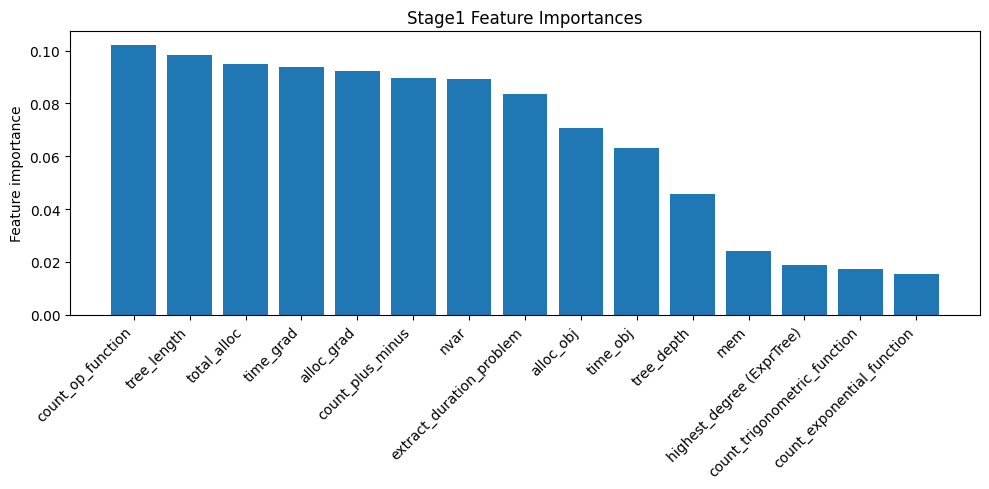

Random Forest Stage 1: MSE=1.3814  R²=0.5715


In [45]:
stage_1 = joblib.load('./model_weights/best_rf_model_reg.pkl')
# best_model = random_search.best_estimator_
rf_importances = stage_1.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(feature_cols_reg)), [feature_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Stage1 Feature Importances")
plt.tight_layout()
plt.show()

pred = stage_1.predict(X_test)
test_mse = mean_squared_error(y_test, pred)
test_r2  = r2_score(y_test, pred)
print(f"Random Forest Stage 1: MSE={test_mse:.4f}  R²={test_r2:.4f}")

### Pipeline 2

In [46]:
X_train_time = stage_1.predict(X_train)
X_test_time  = stage_1.predict(X_test)
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time  = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [47]:
stage2 = joblib.load('./model_weights/best_xgb_model_time.pkl')
pred = stage2.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"Gradient Boosting Stage2: MSE={test_mse:.4f}  R\u00b2={test_r2:.4f}")

Gradient Boosting Stage2: MSE=2.3813  R²=0.4727


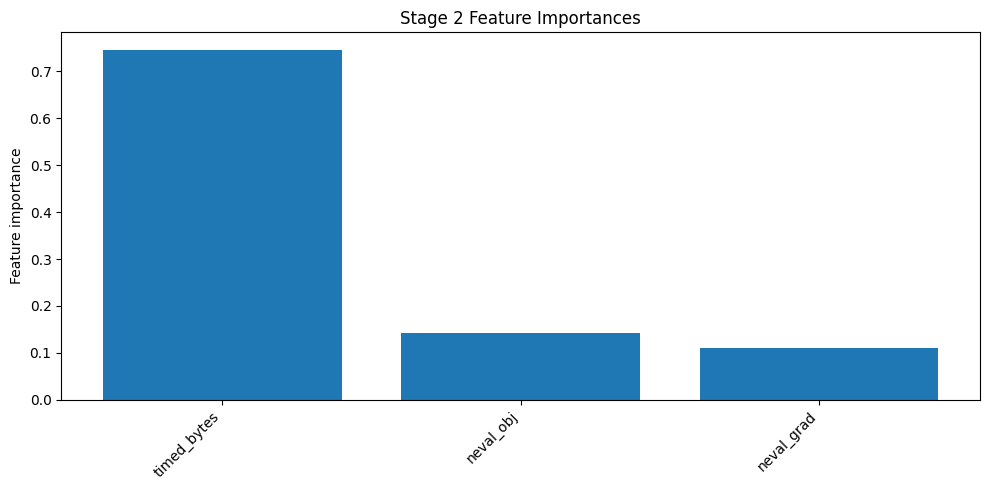

In [48]:
xgb_importances_time = stage2.feature_importances_
indices_xgb = np.argsort(xgb_importances_time)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), xgb_importances_time[indices_xgb])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_xgb], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Stage 2 Feature Importances")
plt.tight_layout()
plt.show()

### Final Mem Selection

In [49]:
test_df["predicted_time"] = stage2.predict(X_test_time)
test_df["predicted_time"]

0       0.392726
1       0.217035
2      -0.209207
3      -0.209207
4      -0.209207
          ...   
4295    2.914669
4296    2.914669
4297    1.672026
4298    1.672026
4299    2.914669
Name: predicted_time, Length: 4300, dtype: float32

In [50]:
group_cols = ["name", "nvar"]
best_idx = df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = df.loc[best_idx].set_index(group_cols)["mem"]
df["best_observed_mem"] = df.set_index(group_cols).index.map(best_mem_map)

In [51]:
group_cols = ["name", "nvar"]
best_idx = test_df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = test_df.loc[best_idx].set_index(group_cols)["mem"]
test_df["best_observed_mem"] = test_df.set_index(group_cols).index.map(best_mem_map)
test_df["best_observed_time"] = test_df.groupby(group_cols)["stats_elapsed_time"].transform("min")

In [52]:
group_cols = ["name", "nvar"]
best_idx = test_df.groupby(group_cols)["predicted_time"].idxmin()
model_time_map = test_df.loc[best_idx].set_index(group_cols)["stats_elapsed_time"]
best_mem_map = test_df.loc[best_idx].set_index(group_cols)["mem"]
test_df["best_predicted_time"] = test_df.set_index(group_cols).index.map(model_time_map)
test_df["best_predicted_mem"] = test_df.set_index(group_cols).index.map(best_mem_map)

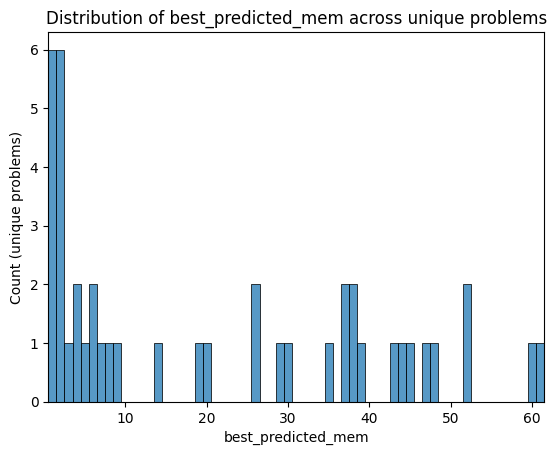

In [53]:
x = test_df.groupby(['name', 'nvar'])['best_predicted_mem'].first()
sns.histplot(x=x, discrete=True)
plt.xlim(0.5, x.max() + 0.5)
plt.xlabel("best_predicted_mem")
plt.ylabel("Count (unique problems)")
plt.title("Distribution of best_predicted_mem across unique problems")
plt.show()

In [54]:
test_df.groupby(['name', 'nvar'])[['best_predicted_mem', 'best_observed_mem', 'predicted_time', 'stats_elapsed_time', 'best_observed_time', 'best_predicted_time']].first()

,,best_predicted_mem,best_observed_mem,predicted_time,stats_elapsed_time,best_observed_time,best_predicted_time
name,nvar,,,,,,
arglinb,100,26,1,0.392726,0.000229,0.000229,0.000409
argtrig,100,4,61,0.802749,0.013453,0.008126,0.011440
arwhead,1000,47,3,1.205853,0.058931,0.040062,0.046104
brownal,100,43,1,-0.204737,0.000280,0.000280,0.000541
brybnd,10000,2,1,2.302641,23.019709,23.019709,25.739328
clplatea,961,4,97,2.924840,16.738348,1.057629,3.078292
clplatec,100,2,87,0.030185,0.999100,0.012869,1.029884
cosine,100,52,1,2.668142,0.000634,0.000634,0.001208
cragglvy,1000,2,12,0.508065,0.415430,0.247496,0.319051


Proportions of best_predicted_mem:
best_predicted_mem
1     0.139535
2     0.139535
3     0.023256
4     0.046512
5     0.023256
6     0.046512
7     0.023256
8     0.023256
9     0.023256
14    0.023256
19    0.023256
20    0.023256
26    0.046512
29    0.023256
30    0.023256
35    0.023256
37    0.046512
38    0.046512
39    0.023256
43    0.023256
44    0.023256
45    0.023256
47    0.023256
48    0.023256
52    0.046512
60    0.023256
61    0.023256
Name: proportion, dtype: float64


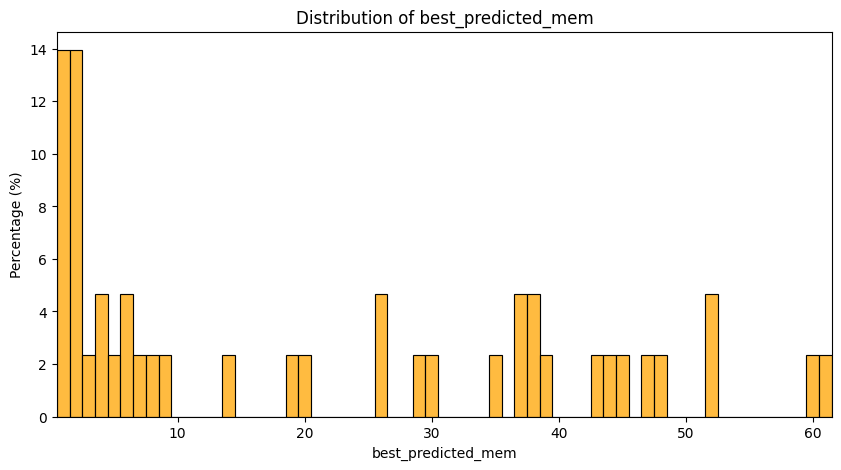

In [55]:
x = test_df["best_predicted_mem"]
proportions = x.value_counts(normalize=True).sort_index()

print("Proportions of best_predicted_mem:")
print(proportions)

plt.figure(figsize=(10, 5))
sns.histplot(x=x, stat='percent', discrete=True, color='orange')
plt.xlabel("best_predicted_mem")
plt.ylabel("Percentage (%)")
plt.title("Distribution of best_predicted_mem")
plt.xlim(0.5, x.max() + 0.5)
plt.show()

### Mem evaluation metrics

In [56]:
# How far off is the predicted mem from actual (in mem units)
mem_absolute_error = abs(test_df['best_predicted_mem'] - test_df['best_observed_mem'])
mame = np.mean(mem_absolute_error)
print(f"Mean Absolute Mem Error: {mame:.2f}")
print(f"Median Absolute Mem Error: {np.median(mem_absolute_error):.2f}")

Mean Absolute Mem Error: 42.65
Median Absolute Mem Error: 42.00


In [57]:
# How close are the predictions? 1.0 = perfect, 0.0 = very far
mem_match_ratio = np.minimum(test_df['best_predicted_mem'], 
                              test_df['best_observed_mem']) / \
                  np.maximum(test_df['best_predicted_mem'], 
                              test_df['best_observed_mem'])

mean_match_ratio = np.mean(mem_match_ratio)
print(f"Mean Mem Match Ratio: {mean_match_ratio:.3f}")
# 1.0 = perfect match
# 0.5 = off by 2x (e.g., pred=50, actual=100)
# 0.1 = off by 10x (e.g., pred=10, actual=100)

Mean Mem Match Ratio: 0.255


In [58]:
group_cols = ['name', 'nvar']
unique_problems = test_df.groupby(group_cols).first().reset_index()

print(f"Total unique test problems: {len(unique_problems)}\n")

Total unique test problems: 43



In [59]:
print("="*60)
print("MEM PREDICTION ACCURACY")
print("="*60)

exact_match = (unique_problems['best_predicted_mem'] == unique_problems['best_observed_mem']).mean()
print(f"Exact match rate: {exact_match:.1%}")

within_5 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 5).mean()
within_10 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 10).mean()
within_20 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 20).mean()

print(f"\nWithin tolerance:")
print(f"  ± 5 mem units:  {within_5:.1%}")
print(f"  ± 10 mem units: {within_10:.1%}")
print(f"  ± 20 mem units: {within_20:.1%}")

MEM PREDICTION ACCURACY
Exact match rate: 4.7%

Within tolerance:
  ± 5 mem units:  16.3%
  ± 10 mem units: 18.6%
  ± 20 mem units: 25.6%


### Baseline Comparison

In [60]:
if 'baseline1_time' in test_df.columns:
    test_df = test_df.drop(columns='baseline1_time')
baseline1_values = df[df['mem'] == 5][['name', 'nvar', 'stats_elapsed_time']].drop_duplicates(['name', 'nvar'])
test_df = test_df.merge(
    baseline1_values.rename(columns={'stats_elapsed_time': 'baseline1_time'}), 
    on=['name', 'nvar'], 
    how='left'
)
test_df

,tree_length,tree_depth,extract_duration_problem,name,count_plus_minus,time_grad,neval_grad,count_exponential_function,count_trigonometric_function,alloc_grad,count_op_function,time_obj,stats_elapsed_time,mem,timed_bytes,nvar,alloc_obj,neval_obj,total_alloc,highest_degree (ExprTree),mem_count,predicted_time,best_observed_mem,best_observed_time,best_predicted_time,best_predicted_mem,baseline1_time
0,40200.0,8.0,6.859471,arglinb,400.0,1.029701,8.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000229,1,20176.0,100,45676488.0,56.0,98224056.0,2.0,100,0.392726,1,0.000229,0.000409,26,0.000234
1,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000294,2,23720.0,100,45676488.0,28.0,98224056.0,2.0,100,0.217035,1,0.000229,0.000409,26,0.000234
2,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000294,3,27192.0,100,45676488.0,28.0,98224056.0,2.0,100,-0.209207,1,0.000229,0.000409,26,0.000234
3,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000236,4,30728.0,100,45676488.0,28.0,98224056.0,2.0,100,-0.209207,1,0.000229,0.000409,26,0.000234
4,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000234,5,34200.0,100,45676488.0,28.0,98224056.0,2.0,100,-0.209207,1,0.000229,0.000409,26,0.000234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4295,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.757891,96,31484720.0,10000,75185144.0,68.0,546412448.0,2.0,100,2.914669,12,7.359282,31.997559,1,9.446440
4296,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.755893,97,31804864.0,10000,75185144.0,68.0,546412448.0,2.0,100,2.914669,12,7.359282,31.997559,1,9.446440
4297,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.753765,98,32125008.0,10000,75185144.0,68.0,546412448.0,2.0,100,1.672026,12,7.359282,31.997559,1,9.446440
4298,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.755922,99,32445152.0,10000,75185144.0,68.0,546412448.0,2.0,100,1.672026,12,7.359282,31.997559,1,9.446440


In [61]:
GLOBAL_BEST_MEM = 87
if 'baseline2_time' in test_df.columns:
    test_df = test_df.drop(columns='baseline2_time')
baseline2_values = df[df['mem'] == GLOBAL_BEST_MEM][['name', 'nvar', 'stats_elapsed_time']].drop_duplicates(['name', 'nvar'])
test_df = test_df.merge(
    baseline2_values.rename(columns={'stats_elapsed_time': 'baseline2_time'}), 
    on=['name', 'nvar'], 
    how='left'
)
test_df

,tree_length,tree_depth,extract_duration_problem,name,count_plus_minus,time_grad,neval_grad,count_exponential_function,count_trigonometric_function,alloc_grad,count_op_function,time_obj,stats_elapsed_time,mem,timed_bytes,nvar,alloc_obj,neval_obj,total_alloc,highest_degree (ExprTree),mem_count,predicted_time,best_observed_mem,best_observed_time,best_predicted_time,best_predicted_mem,baseline1_time,baseline2_time
0,40200.0,8.0,6.859471,arglinb,400.0,1.029701,8.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000229,1,20176.0,100,45676488.0,56.0,98224056.0,2.0,100,0.392726,1,0.000229,0.000409,26,0.000234,0.000289
1,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000294,2,23720.0,100,45676488.0,28.0,98224056.0,2.0,100,0.217035,1,0.000229,0.000409,26,0.000234,0.000289
2,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000294,3,27192.0,100,45676488.0,28.0,98224056.0,2.0,100,-0.209207,1,0.000229,0.000409,26,0.000234,0.000289
3,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000236,4,30728.0,100,45676488.0,28.0,98224056.0,2.0,100,-0.209207,1,0.000229,0.000409,26,0.000234,0.000289
4,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000234,5,34200.0,100,45676488.0,28.0,98224056.0,2.0,100,-0.209207,1,0.000229,0.000409,26,0.000234,0.000289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4295,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.757891,96,31484720.0,10000,75185144.0,68.0,546412448.0,2.0,100,2.914669,12,7.359282,31.997559,1,9.446440,7.757396
4296,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.755893,97,31804864.0,10000,75185144.0,68.0,546412448.0,2.0,100,2.914669,12,7.359282,31.997559,1,9.446440,7.757396
4297,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.753765,98,32125008.0,10000,75185144.0,68.0,546412448.0,2.0,100,1.672026,12,7.359282,31.997559,1,9.446440,7.757396
4298,42500.0,7.0,74.643566,woods,27501.0,1.054803,59.0,0.0,0.0,471227304.0,57501.0,0.113105,7.755922,99,32445152.0,10000,75185144.0,68.0,546412448.0,2.0,100,1.672026,12,7.359282,31.997559,1,9.446440,7.757396


In [62]:
test_df = test_df.rename(columns={'best_observed_time' : 'oracle_time'})
test_df.head(41)

,tree_length,tree_depth,extract_duration_problem,name,count_plus_minus,time_grad,neval_grad,count_exponential_function,count_trigonometric_function,alloc_grad,count_op_function,time_obj,stats_elapsed_time,mem,timed_bytes,nvar,alloc_obj,neval_obj,total_alloc,highest_degree (ExprTree),mem_count,predicted_time,best_observed_mem,oracle_time,best_predicted_time,best_predicted_mem,baseline1_time,baseline2_time
0,40200.0,8.0,6.859471,arglinb,400.0,1.029701,8.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000229,1,20176.0,100,45676488.0,56.0,98224056.0,2.0,100,0.392726,1,0.000229,0.000409,26,0.000234,0.000289
1,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000294,2,23720.0,100,45676488.0,28.0,98224056.0,2.0,100,0.217035,1,0.000229,0.000409,26,0.000234,0.000289
2,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000294,3,27192.0,100,45676488.0,28.0,98224056.0,2.0,100,-0.209207,1,0.000229,0.000409,26,0.000234,0.000289
3,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000236,4,30728.0,100,45676488.0,28.0,98224056.0,2.0,100,-0.209207,1,0.000229,0.000409,26,0.000234,0.000289
4,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000234,5,34200.0,100,45676488.0,28.0,98224056.0,2.0,100,-0.209207,1,0.000229,0.000409,26,0.000234,0.000289
5,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000237,6,37736.0,100,45676488.0,28.0,98224056.0,2.0,100,0.249594,1,0.000229,0.000409,26,0.000234,0.000289
6,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000235,7,41208.0,100,45676488.0,28.0,98224056.0,2.0,100,0.000896,1,0.000229,0.000409,26,0.000234,0.000289
7,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000438,8,44744.0,100,45676488.0,28.0,98224056.0,2.0,100,0.249594,1,0.000229,0.000409,26,0.000234,0.000289
8,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000426,9,48216.0,100,45676488.0,28.0,98224056.0,2.0,100,0.249594,1,0.000229,0.000409,26,0.000234,0.000289
9,40200.0,8.0,6.859471,arglinb,400.0,1.029701,4.0,0.0,0.0,52547568.0,20600.0,0.288629,0.000431,10,51752.0,100,45676488.0,28.0,98224056.0,2.0,100,0.249594,1,0.000229,0.000409,26,0.000234,0.000289


In [63]:
# Model Regret (The memory value predicted by your RF)
test_df['model_regret'] = test_df['best_predicted_time'] - test_df['oracle_time']

# Baseline 1 Regret (Always using mem=5)
test_df['baseline1_regret'] = test_df['baseline1_time'] - test_df['oracle_time']

# Baseline 2 Regret (Always using the best fixed memory found in training)
test_df['baseline2_regret'] = test_df['baseline2_time'] - test_df['oracle_time']
test_df_unique = test_df.groupby(["name", "nvar"]).first()

test_df[test_df["model_regret"] == test_df["model_regret"].max()].head(1)

,tree_length,tree_depth,extract_duration_problem,name,count_plus_minus,time_grad,neval_grad,count_exponential_function,count_trigonometric_function,alloc_grad,count_op_function,time_obj,stats_elapsed_time,mem,timed_bytes,nvar,alloc_obj,neval_obj,total_alloc,highest_degree (ExprTree),mem_count,predicted_time,best_observed_mem,oracle_time,best_predicted_time,best_predicted_mem,baseline1_time,baseline2_time,model_regret,baseline1_regret,baseline2_regret
3800,200000.0,8.0,6837.626028,tquartic,199999.0,31.543323,86.0,0.0,0.0,2.324150e+10,499996.0,0.06945,2217.34013,1,10435968.0,100000,73692560.0,120.0,2.331519e+10,2.0,100,5.348051,75,471.37338,2217.34013,1,910.060156,607.036532,1745.96675,438.686776,135.663152


In [64]:
print("\n" + "="*40)
print("AVERAGE REGRET (SECONDS ABOVE ORACLE)")
print("="*40)
print(test_df_unique[['model_regret', 'baseline1_regret', 'baseline2_regret']].mean().to_string())

print("\n" + "="*40)
print("REGRET QUANTILES (50% / 75% / 95%)")
print("="*40)
print(test_df_unique[['model_regret', 'baseline1_regret', 'baseline2_regret']].quantile([0.5, 0.75, 0.95]))


AVERAGE REGRET (SECONDS ABOVE ORACLE)
model_regret        59.626199
baseline1_regret    25.146670
baseline2_regret     5.722437

REGRET QUANTILES (50% / 75% / 95%)
      model_regret  baseline1_regret  baseline2_regret
0.50      0.088288          0.267955          0.095412
0.75      7.366861          5.712914          0.670555
0.95    117.704532         67.109141         17.816225


In [65]:
# Calculate ratios per problem (Relative Slowdown)
test_df_unique['model_ratio'] = test_df_unique['best_predicted_time'] / test_df_unique['oracle_time']
test_df_unique['baseline1_ratio'] = test_df_unique['baseline1_time'] / test_df_unique['oracle_time']
test_df_unique['baseline2_ratio'] = test_df_unique['baseline2_time'] / test_df_unique['oracle_time']

# Print the comparison
print("\n" + "="*40)
print("PERFORMANCE RATIO (1.0 = PERFECTION)")
print("="*40)
cols = ['model_ratio', 'baseline1_ratio', 'baseline2_ratio']
print(test_df_unique[cols].quantile([0.5, 0.75, 0.95]))


PERFORMANCE RATIO (1.0 = PERFECTION)
      model_ratio  baseline1_ratio  baseline2_ratio
0.50     1.421028         1.233671         1.111844
0.75     1.908403         1.782548         1.476112
0.95     5.460834         5.278511         2.266124
